In [9]:
# Note: 
# 1. You need to be connected to the HKU network or HKU VPN to access the chenlin04 server.
# 2. Do not upload chenlin04_student_login.txt to any public repository, such as GitHub and LLMs.
# 3. Contact Boao (boaozhan@connect.hku.hk) for any questions related to accessing/using the LinkUp data.

In [10]:
import pandas as pd
import requests
import clickhouse_connect
from collections import namedtuple

In [ ]:
class SimpleResult:
    def __init__(self, json_data):
        self.result_rows = json_data.get('data', [])
        self.column_names = [meta['name'] for meta in json_data.get('meta', [])]

class SimpleClient:
    def __init__(self, host, username, password, **kwargs):
        self.base_url = f"http://{host}:8123/"
        self.auth = {
            'user': username,
            'password': password
        }
        
    def query(self, query_string):
        params = self.auth.copy()
        # Use JSON format to get metadata (column names) easily
        params['query'] = query_string + " FORMAT JSON"
        
        response = requests.get(self.base_url, params=params)
        
        if response.status_code != 200:
            raise Exception(f"Query failed: {response.text}")
            
        return SimpleResult(response.json())

# Initialize the client
with open('../chenlin04_student_login.txt', 'r') as f:
    conn_info = eval(f.read())
    try:
        # Try to connect with clickhouse first
        client = clickhouse_connect.get_client(**conn_info)
        print("Connected using standard clickhouse_connect")
    except Exception as e:
        # If it doesn't work out, use requests
        print(f"Standard connection failed: {e}")
        print("Falling back to SimpleClient (lightweight mode)...")
        client = SimpleClient(**conn_info)
        print("Connected using SimpleClient")

Connected using standard clickhouse_connect


In [12]:
res = client.query("""show tables from fina4359_linkup_202603""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables.to_excel("my_query_results.xlsx", index=False)

print("Data exported to my_query_results.xlsx")

Data exported to my_query_results.xlsx


In [13]:
# company_id_compustat_identifiers is the mapping file between company_id and standard compustat identifiers
# company_id is the unique identifier for each company in the linkup database. It's used within this database only.
# compustat identifiers include gvkey, cusip, and tic. They are standard identifiers used in the financial industry and can be used to link to other databases.
# naics is the industry classification code for the company. See more from https://www.naics.com.

res = client.query("""select * from fina4359_linkup_202603.company_id_compustat_identifiers limit 5""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,company_id,cusip,gvkey,tic,conm,naics
0,20238,898402102,4685,TRMK,TRUSTMARK CORP,522110.0
1,43730,881569107,170969,TSRO,TESARO INC,325414.0
2,44223,539830109,6774,LMT,LOCKHEED MARTIN CORP,336414.0
3,12903,10948C107,33637,BV,BRIGHTVIEW HOLDINGS,541320.0
4,17378,38268T103,20644,GPRO,GOPRO INC,333316.0


In [14]:
res = client.query("""select * from fina4359_linkup_202603.company_id_compustat_identifiers
                   where tic = 'NKE'""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,company_id,cusip,gvkey,tic,conm,naics
0,10467,654106103,7906,NKE,NIKE INC -CL B,316210.0


In [15]:
# The job postings of a company with company_id x can be accessed through the table fina4359_linkup_202603.firm_x
# hash: unique identifier for each job posting.
# onet: occupation code for the job posting. See more from https://www.onetonline.org.
# created, last_updated, last_seen, and missing: date on which the job posting is created, last updated, last seen, and not seen anymore by the crawler.

res = client.query("""select * from fina4359_linkup_202603.firm_10467 limit 5""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,description
0,0489e44cfda10132c1061d8aeff1692d,15119909.0,1,24,97228.0,2016-10-08,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
1,094b60f6a344771862769e2570220e28,41203100.0,1,20,55122.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
2,0c5fffb23fcf90bdb359d6f2046f0806,41203100.0,1,2,77429.0,2017-01-06,None,0,2017-01-29,2017-02-01,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
3,0a28eddba451425b131ff6d0413035f2,41203100.0,1,2,77502.0,2016-09-02,None,0,2017-02-07,2017-02-09,"Become a Part of the NIKE, Inc. Team\n\nNIKE, ..."
4,0b4fabe2406bdd38698a8c60a3e0e64d,27202100.0,1,4,10601.0,2016-10-04,None,0,2017-02-03,2017-02-05,Work Hard. Play Hard.


In [16]:
# A job from Nike's latest job postings.

res = client.query("""select * from fina4359_linkup_202603.firm_10467 order by created desc limit 1""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,hash,onet,country,state,zip,created,last_updated,updates,last_seen,missing,description
0,15df67fabcfac7c9ec29e13710ba6973,13111100.0,1,24,97075.0,2022-09-29,None,0,2022-09-29,None,Who we are looking for\n \nWe are looking for...


In [17]:
# A job from Nike's latest job postings.

res = client.query("""with T1 as (
                    select max(created) as latest_created from fina4359_linkup_202603.firm_10467
                   )
                   select description from fina4359_linkup_202603.firm_10467 
                   where created = (select latest_created from T1) 
                   limit 1""")
test_job = res.result_rows
test_job

[("About the Role &amp; Team\\n  \\nAs a Principal Quality Engineer, you will be responsible for designing and implementing the Quality Engineering capabilities for Nike's Planning and Manufacturing Products. You will work on defining strategy, roadmap and implement quality focused governance, KPI's and metrics.\\n  \\nPartner with different product teams in creation and implementation of test assets \\u2014 test plans, cases, data, and reports. As an Expert Quality Engineer, you will be responsible for strategy, planning, execution tracking and reporting to validate technology solutions as per quality standards. You will be working along the product and engineering teams implementing quality frameworks and agile practices to enable speed to market of technology products. You will be responsible to ensure projects meet quality standards by providing technical guidance in planning, designing, and completing testing and developing procedures relating to product quality on complex project

In [18]:
print(test_job[0]['description'].replace('\\n', '\n'))

TypeError: tuple indices must be integers or slices, not str

In [19]:
# Mapping between country names and state codes. 0 means unknown.

res = client.query("""select * from fina4359_linkup_202603.country_state_code_mapping limit 5""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,country,state,country_name,state_name
0,0,0,None,None
1,0,1,None,CA
2,0,2,None,TX
3,0,3,None,FL
4,0,4,None,VA


In [ ]:
# Compustat North America quarterly data for all firms available in WRDS since 2000. 
# See variable definitions from Compustat_Understanding_The_Data.pdf. 

res = client.query("""select * from fina4359_linkup_202603.compustat_na_quarterly_all_firms_since_2000 limit 5""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables


,costat,curcdq,datafmt,indfmt,consol,tic,datadate,gvkey,conm,cusip,...,seqq,txditcq,txtq,xintq,xsgaq,capxy,fincfy,ivncfy,oancfy,prccq
0,I,USD,STD,INDL,C,ADCT.1,2000-01-31,1013,ADC TELECOMMUNICATIONS INC,000886309,...,1396.005,0.000,15.300,NaN,205.600,46.785,16.289,-35.692,41.582,65.9375
1,I,USD,STD,INDL,C,SERV.1,2000-01-31,1082,SERVIDYNE INC,81765M106,...,21.270,4.009,-0.119,1.374,2.169,9.597,-4.911,-3.077,5.032,3.5000
2,I,USD,STD,INDL,C,AIM.1,2000-01-31,1173,AEROSONIC CORP,008015307,...,12.644,0.155,0.064,0.136,1.839,0.558,0.528,-0.558,-0.724,10.9375
3,I,USD,STD,INDL,C,IDAI.,2000-01-31,1183,IDNA INC,45169P106,...,83.879,0.000,-3.286,NaN,NaN,1.091,-2.582,43.731,-18.925,0.8400
4,I,CAD,STD,INDL,C,AGR.7,2000-01-31,1189,AGRA INDUSTRIES LTD,008489502,...,363.297,0.000,4.205,4.766,NaN,17.181,32.244,-23.324,-21.550,11.1000


In [20]:
# CRSP monthly return data for all firms available in WRDS since 2000.
# DIVAMT: cash dividend amount.
# PRC: price at the end of the month.
# VOL: trading volume during the month.
# RET: monthly return. Calculated as (PRC - lag(PRC) + DIVAMT) / lag(PRC).
# ALTPRC: alternative price when PRC is not available.
# RETX: return without dividends, calculated as (PRC - lag(PRC)) / lag(PRC).

res = client.query("""select * from fina4359_linkup_202603.crsp_monthly_ret_all_firms_since_2000 limit 5""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,PERMNO,date,TICKER,COMNAM,PERMCO,CUSIP,DIVAMT,PRC,VOL,RET,ALTPRC,RETX
0,10001,20000131,EWST,ENERGY WEST INC,7953,36720410,NaN,8.12500,403.0,-0.044118,8.12500,-0.044118
1,10001,20000229,EWST,ENERGY WEST INC,7953,36720410,NaN,8.25000,222.0,0.015385,8.25000,0.015385
2,10001,20000331,EWST,ENERGY WEST INC,7953,36720410,0.12,-8.00000,723.0,-0.015758,-8.00000,-0.030303
3,10001,20000428,EWST,ENERGY WEST INC,7953,36720410,NaN,-8.09375,263.0,0.011719,-8.09375,0.011719
4,10001,20000531,EWST,ENERGY WEST INC,7953,36720410,NaN,-7.90625,221.0,-0.023166,-7.90625,-0.023166


In [ ]:
# For each company that can be found in company_id_compustat_identifiers, what is their average atq in 2020?

res = client.query("""with compustat_2020 as (
                    select gvkey, atq from fina4359_linkup_202603.compustat_na_quarterly_all_firms_since_2000
                    where datadate >= '2020-01-01' and datadate <= '2020-12-31'
                   )
                   select c.company_id, avg(t.atq) as avg_atq_2020 
                   from compustat_2020 t
                   join fina4359_linkup_202603.company_id_compustat_identifiers c
                   on t.gvkey = c.gvkey
                   group by c.company_id""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

,company_id,avg_atq_2020
0,21744,1906.94925
1,22452,10540.75225
2,11440,2028.58175
3,26972,484.05150
4,20503,504744.00000
...,...,...
354,20531,1953.76500
355,53143,2467.79300
356,65176,162.48600
357,44919,8695.50000


In [21]:
# On top of the previous table, add another column showing the stock return in 2020-12.

res = client.query("""with compustat_2020 as (
                    select gvkey, atq from fina4359_linkup_202603.compustat_na_quarterly_all_firms_since_2000
                    where datadate >= '2020-01-01' and datadate <= '2020-12-31'
                   ),
crsp_2020 as (
                    select cusip, ret from fina4359_linkup_202603.crsp_monthly_ret_all_firms_since_2000
                    where date >= '2020-12-01' and date <= '2020-12-31'
                   )
                   select c.company_id, avg(t.atq) as avg_atq_2020, r.ret as dec_2020_return
                   from compustat_2020 t
                   join fina4359_linkup_202603.company_id_compustat_identifiers c
                   on t.gvkey = c.gvkey
                   left join crsp_2020 r
                   on c.cusip = r.cusip
                   group by c.company_id, r.ret""")
df_tables = pd.DataFrame(res.result_rows, columns=res.column_names)
df_tables

DatabaseError: Received ClickHouse exception, code: 47, server response: Code: 47. DB::Exception: Unknown expression identifier `ret` in scope  crsp_2020 AS r. Maybe you meant: ['RET']. (UNKNOWN_IDENTIFIER) (for url http://chenlin04.fbe.hku.hk:8123)

In [29]:
import pandas as pd

# 1. 獲取 Mag 7 識別碼
id_query = """
    SELECT company_id, tic 
    FROM fina4359_linkup_202603.company_id_compustat_identifiers 
    WHERE tic IN ('NVDA', 'TSLA', 'AAPL', 'META', 'AMZN', 'MSFT', 'GOOGL')
"""
df_ids = pd.DataFrame(client.query(id_query).result_rows, columns=['company_id', 'tic'])

table_queries = []
for _, row in df_ids.iterrows():
    c_id = row['company_id']
    ticker = row['tic']
    
    # 這裡我們使用 onet (職業代碼) 來分類，因為這是你截圖中確定的欄位
    # 15-xxxx 是電腦/數學 (AI), 41-xxxx 是銷售, 11/13-xxxx 是管理/營運
    sub_query = f"""
        SELECT 
            '{ticker}' AS ticker,
            toStartOfMonth(toDate(created)) AS month,
            CASE 
                WHEN onet >= 150000 AND onet < 160000 THEN 'R&D_AI'
                WHEN onet >= 410000 AND onet < 420000 THEN 'Sales_Mkt'
                WHEN (onet >= 110000 AND onet < 140000) OR (onet >= 430000 AND onet < 440000) THEN 'Ops_Supply'
                ELSE 'Other'
            END AS functional_category,
            count(*) AS job_count
        FROM fina4359_linkup_202603.firm_{c_id}
        WHERE created IS NOT NULL
        GROUP BY ticker, month, functional_category
    """
    table_queries.append(sub_query)

final_query = " UNION ALL ".join(table_queries) + " ORDER BY month DESC"
res = client.query(final_query)
df_mag7 = pd.DataFrame(res.result_rows, columns=res.column_names)

# 整理成 Presentation 用的表格
df_pivot = df_mag7.pivot_table(index='month', columns=['ticker', 'functional_category'], values='job_count').fillna(0)
df_pivot.head()

ticker,AMZN,MSFT
functional_category,Other,Other
month,,
2012-06-01,0.0,5.0
2012-12-01,0.0,1.0
2013-01-01,0.0,5.0
2013-03-01,0.0,5.0
2013-04-01,0.0,7.0


In [42]:
import pandas as pd

# 1. 先獲取公司 ID 與 Ticker 的映射表 (確保我們知道 ID 對應哪家公司)
id_map_query = """
    SELECT company_id, tic, conm 
    FROM fina4359_linkup_202603.company_id_compustat_identifiers
"""
df_map = pd.DataFrame(client.query(id_map_query).result_rows, columns=['company_id', 'tic', 'conm'])

# 2. 獲取數據庫中所有以 'firm_' 開頭的實體表名
all_tables_res = client.query("SHOW TABLES FROM fina4359_linkup_202603 LIKE 'firm_%'")
all_firm_tables = [t[0] for t in all_tables_res.result_rows]

stats = []
print(f"掃描開始：數據庫中共有 {len(all_firm_tables)} 張公司表，正在提取樣本...")

# 3. 掃描前 100 張表，找出數據最豐富的公司 (避免全掃太慢)
for table_name in all_firm_tables[:100]:
    c_id = table_name.replace('firm_', '')
    
    # 匹配 Ticker 資訊
    ticker_info = df_map[df_map['company_id'].astype(str) == c_id]
    
    if not ticker_info.empty:
        tic = ticker_info.iloc[0]['tic']
        name = ticker_info.iloc[0]['conm']
        
        try:
            # 獲取該表的總行數和最新日期
            # 注意：這裡日期欄位我們暫時用 created，若報錯會自動跳過
            count_q = f"SELECT count(*), max(toDate(created)) FROM fina4359_linkup_202603.{table_name}"
            res = client.query(count_q).result_rows[0]
            
            stats.append({
                'ticker': tic, 
                'name': name, 
                'rows': res[0], 
                'latest_date': res[1], 
                'table': table_name
            })
        except:
            # 如果這張表沒有 created 欄位，嘗試 job_added_date
            try:
                count_q = f"SELECT count(*), max(toDate(job_added_date)) FROM fina4359_linkup_202603.{table_name}"
                res = client.query(count_q).result_rows[0]
                stats.append({
                    'ticker': tic, 'name': name, 'rows': res[0], 'latest_date': res[1], 'table': table_name
                })
            except:
                continue

# 4. 排序並顯示結果
df_ranking = pd.DataFrame(stats).sort_values(by='rows', ascending=False)

print("\n--- 數據量前 10 名的公司 (你的最佳研究對象) ---")
print(df_ranking[['ticker', 'name', 'rows', 'latest_date']].head(10))

掃描開始：數據庫中共有 378 張公司表，正在提取樣本...

--- 數據量前 10 名的公司 (你的最佳研究對象) ---
   ticker                         name    rows latest_date
68    TEO            TELECOM ARGENTINA  353999  2022-10-03
55   CTSH     COGNIZANT TECH SOLUTIONS  280588  2022-10-03
40    TFC        TRUIST FINANCIAL CORP  236434  2022-10-03
10     VZ   VERIZON COMMUNICATIONS INC  200760  2022-10-02
3     AAN          AARONS CO INC (THE)   91620  2022-10-01
52    AZN              ASTRAZENECA PLC   88788  2022-10-03
76    AMN  AMN HEALTHCARE SERVICES INC   83947  2018-09-18
67    BYD             BOYD GAMING CORP   74567  2022-10-02
0     NKE              NIKE INC  -CL B   72610  2022-09-29
51    JBL                    JABIL INC   49759  2022-10-03


正在生成 10 大公司招聘趨勢圖...


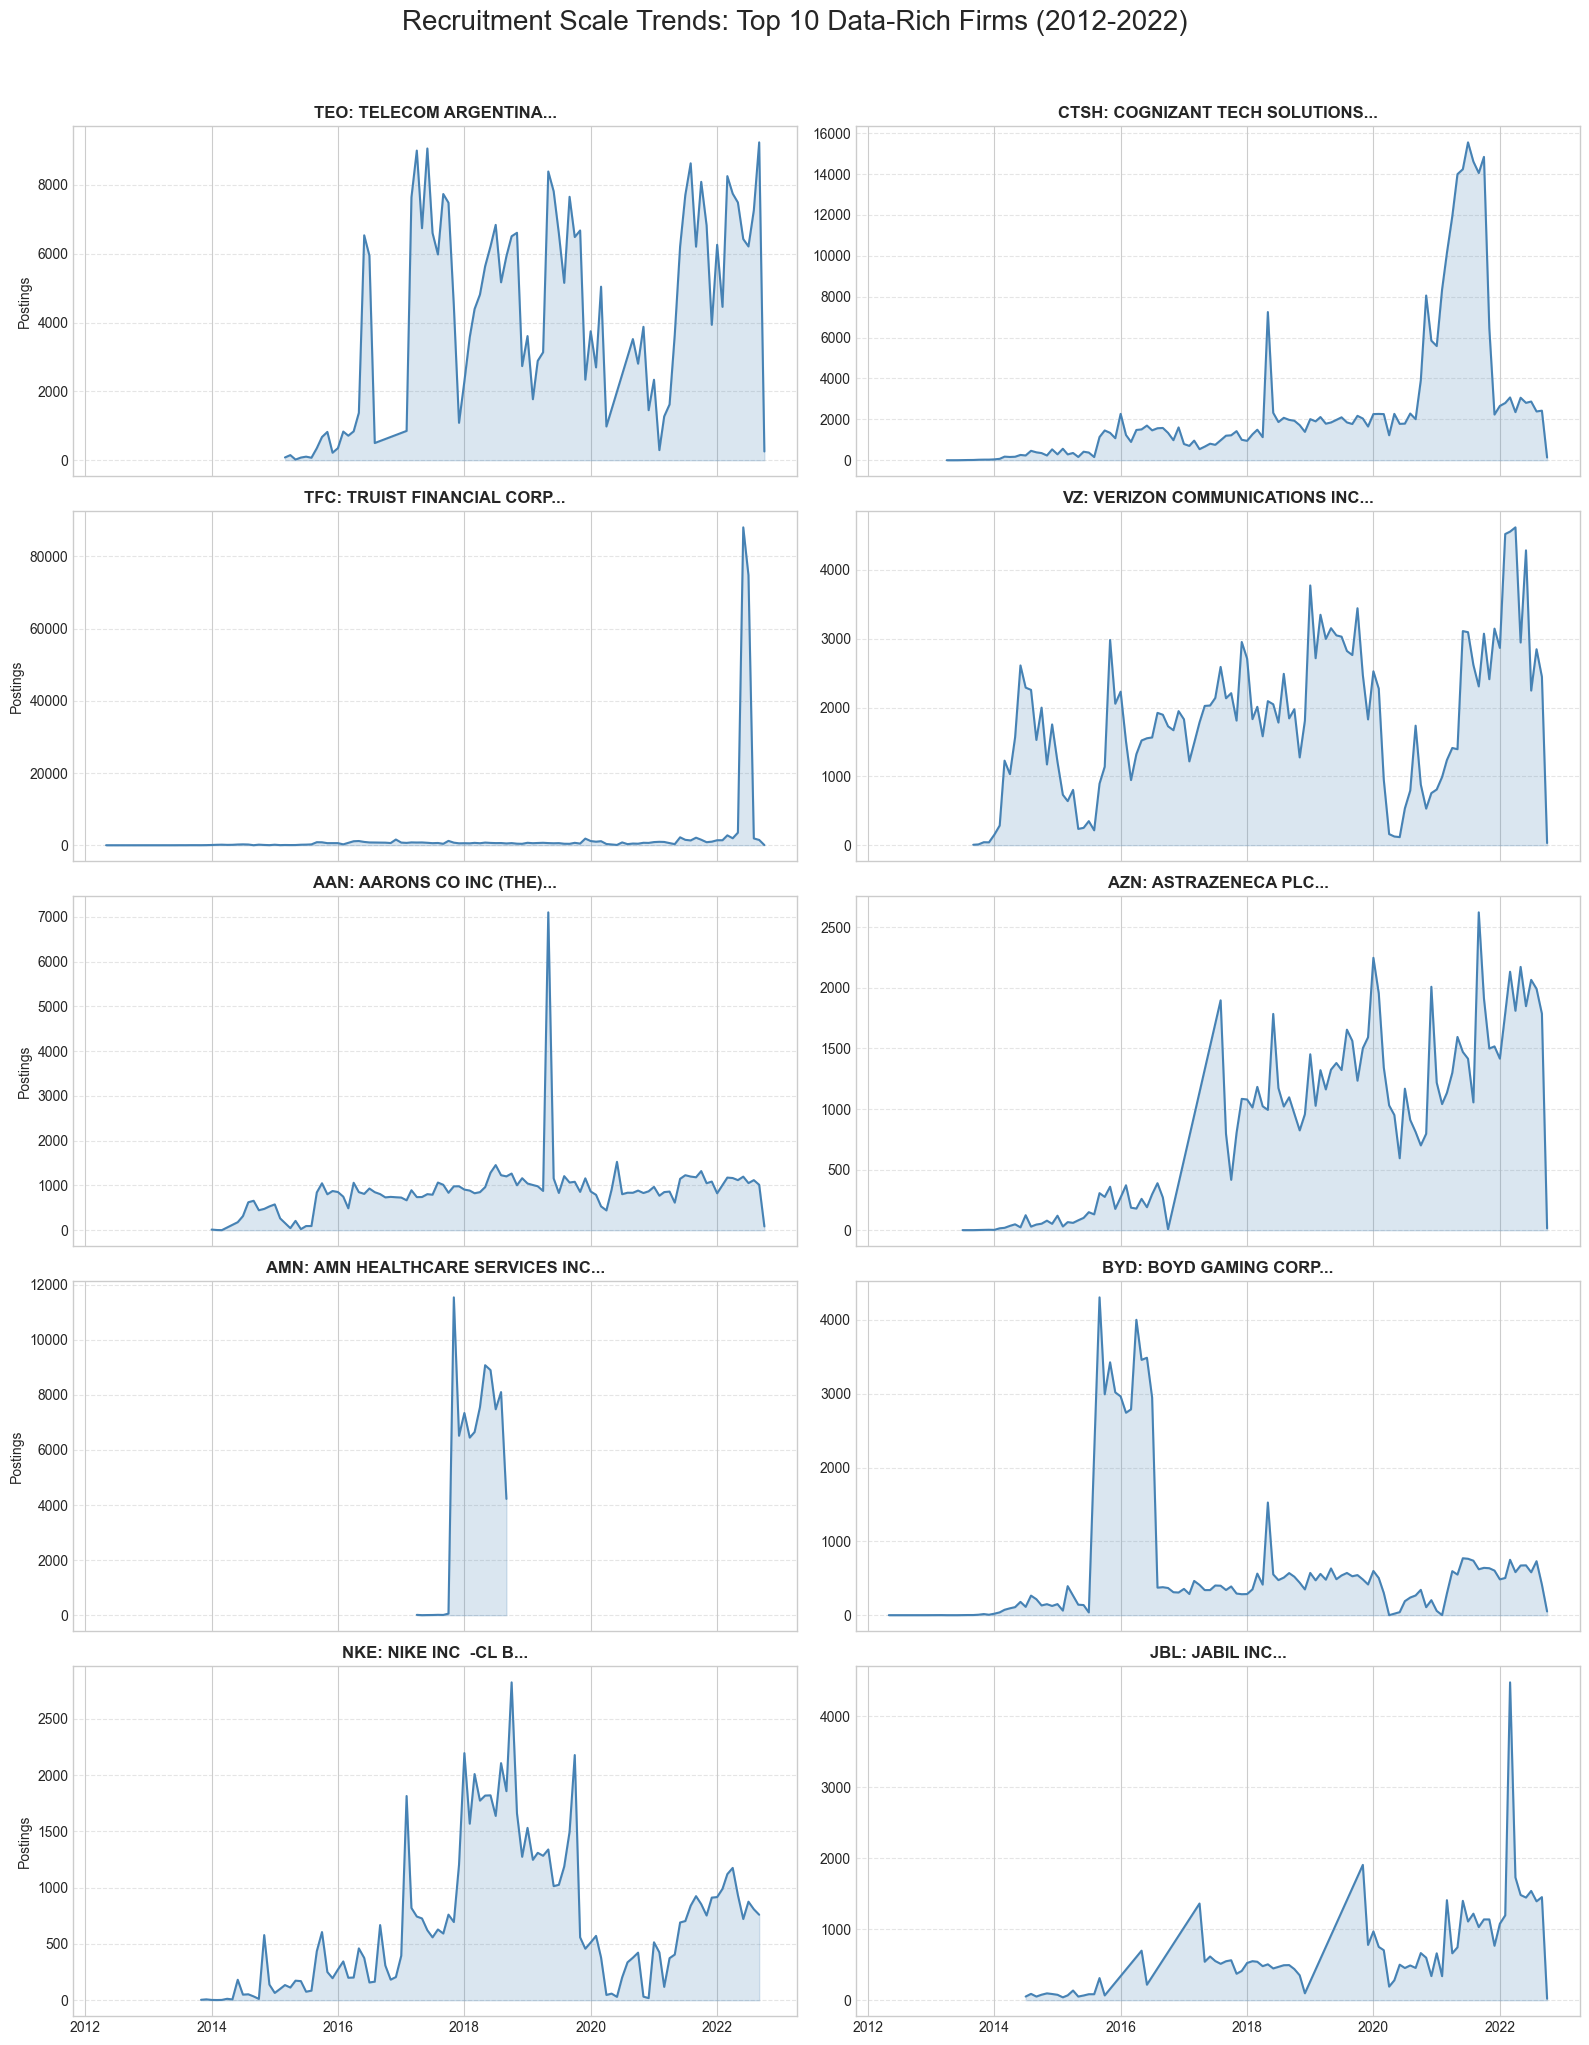

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. 使用你剛才跑出來的 df_ranking (前 10 名)
top_10 = df_ranking.head(10)

# 2. 設定畫布，5行2列
fig, axes = plt.subplots(5, 2, figsize=(16, 20), sharex=True)
axes = axes.flatten()

print("正在生成 10 大公司招聘趨勢圖...")

for i, (idx, row) in enumerate(top_10.iterrows()):
    tic = row['ticker']
    name = row['name']
    table = row['table']
    ax = axes[i]
    
    # SQL 查詢：每月招聘總數
    # 這裡加入 try-except 是為了防止個別表日期欄位名稱不同
    try:
        query = f"""
            SELECT toStartOfMonth(toDate(created)) as month, count(*) as count 
            FROM fina4359_linkup_202603.{table} 
            WHERE created IS NOT NULL GROUP BY month ORDER BY month
        """
        res = client.query(query)
    except:
        query = f"""
            SELECT toStartOfMonth(toDate(job_added_date)) as month, count(*) as count 
            FROM fina4359_linkup_202603.{table} 
            WHERE job_added_date IS NOT NULL GROUP BY month ORDER BY month
        """
        res = client.query(query)
        
    df_temp = pd.DataFrame(res.result_rows, columns=['month', 'count'])
    df_temp['month'] = pd.to_datetime(df_temp['month'])
    
    # 繪圖
    ax.plot(df_temp['month'], df_temp['count'], color='steelblue', lw=1.5)
    ax.fill_between(df_temp['month'], df_temp['count'], alpha=0.2, color='steelblue')
    
    # 美化小圖
    ax.set_title(f"{tic}: {name[:30]}...", fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    if i % 2 == 0:
        ax.set_ylabel('Postings')

# 全體美化
plt.suptitle('Recruitment Scale Trends: Top 10 Data-Rich Firms (2012-2022)', fontsize=20, y=1.02)
plt.tight_layout()
plt.show()

In [52]:
import pandas as pd
import numpy as np
import yfinance as yf

# 1. 確保使用之前篩選出的數據大戶
top_10_firms = df_ranking.head(10)
final_results = []

print("🚀 啟動修復版分析流程 (Solving MultiIndex Error)...")

for _, row in top_10_firms.iterrows():
    tic = row['ticker']
    table = row['table']
    
    # --- A. 獲取招聘數據 ---
    try:
        job_q = f"SELECT toStartOfMonth(toDate(created)) as month, count(*) as job_count FROM fina4359_linkup_202603.{table} WHERE created IS NOT NULL GROUP BY month ORDER BY month"
        job_res = client.query(job_q)
    except:
        job_q = f"SELECT toStartOfMonth(toDate(job_added_date)) as month, count(*) as job_count FROM fina4359_linkup_202603.{table} WHERE job_added_date IS NOT NULL GROUP BY month ORDER BY month"
        job_res = client.query(job_q)
        
    df_job = pd.DataFrame(job_res.result_rows, columns=['month', 'job_count'])
    df_job['month'] = pd.to_datetime(df_job['month'])
    
    if df_job.empty: continue

    # --- B. 使用 yfinance 獲取股價數據 ---
    start_date = df_job['month'].min().strftime('%Y-%m-%d')
    end_date = (df_job['month'].max() + pd.DateOffset(months=2)).strftime('%Y-%m-%d')
    
    try:
        # 關鍵修正：auto_adjust=True 可以減少某些 MultiIndex 帶來的困擾
        stock_data = yf.download(tic, start=start_date, end=end_date, interval='1mo', progress=False, auto_adjust=True)
        
        if stock_data.empty: continue

        # 【核心修正】如果 yfinance 回傳的是 MultiIndex (多層索引)，我們只取第一層
        if isinstance(stock_data.columns, pd.MultiIndex):
            stock_data.columns = stock_data.columns.get_level_values(0)
            
        # 計算月收益率 (有些版本叫 'Close' 有些叫 'Adj Close'，auto_adjust=True 後通常是 'Close')
        price_col = 'Close' if 'Close' in stock_data.columns else 'Adj Close'
        stock_data['ret'] = stock_data[price_col].pct_change()
        
        df_stock = stock_data[['ret']].reset_index()
        df_stock.columns = ['month', 'ret']
        
        # 對齊時間：將 yfinance 的日期統一到每月 1 號
        df_stock['month'] = df_stock['month'].dt.to_period('M').dt.to_timestamp()
        
        # --- C. 合併與計算 ---
        df_merged = pd.merge(df_job, df_stock, on='month').dropna()
        
        if len(df_merged) >= 6:
            sync_corr = df_merged['job_count'].corr(df_merged['ret'])
            # 領先 1 個月相關性
            df_merged['next_ret'] = df_merged['ret'].shift(-1)
            lead_corr = df_merged['job_count'].corr(df_merged['next_ret'])
            
            final_results.append({
                'Ticker': tic,
                'Sync_Corr': round(sync_corr, 4),
                'Lead_Corr': round(lead_corr, 4),
                'Months': len(df_merged)
            })
            print(f"✅ {tic} 分析成功")
            
    except Exception as e:
        print(f"❌ {tic} 失敗: {str(e)[:30]}")

# 3. 顯示最終結果
df_final_corr = pd.DataFrame(final_results).sort_values(by='Lead_Corr', ascending=False)
print("\n" + "="*50)
print(f"{'Final Correlation Report':^50}")
print("="*50)
print(df_final_corr)

🚀 啟動修復版分析流程 (Solving MultiIndex Error)...
✅ TEO 分析成功
✅ CTSH 分析成功
✅ TFC 分析成功
✅ VZ 分析成功


$AAN: possibly delisted; no timezone found

1 Failed download:
['AAN']: possibly delisted; no timezone found


✅ AZN 分析成功
✅ AMN 分析成功
✅ BYD 分析成功
✅ NKE 分析成功
✅ JBL 分析成功

             Final Correlation Report             
  Ticker  Sync_Corr  Lead_Corr  Months
4    AZN    -0.0265     0.0694      99
0    TEO     0.1618    -0.0030      82
2    TFC    -0.0063    -0.0216     118
1   CTSH    -0.0744    -0.0269     114
3     VZ    -0.1009    -0.0383     109
8    JBL     0.0270    -0.0580      74
6    BYD    -0.0912    -0.0582     116
7    NKE    -0.0422    -0.0728     106
5    AMN     0.1064    -0.2939      17


正在從 100 家公司合成總體趨勢...


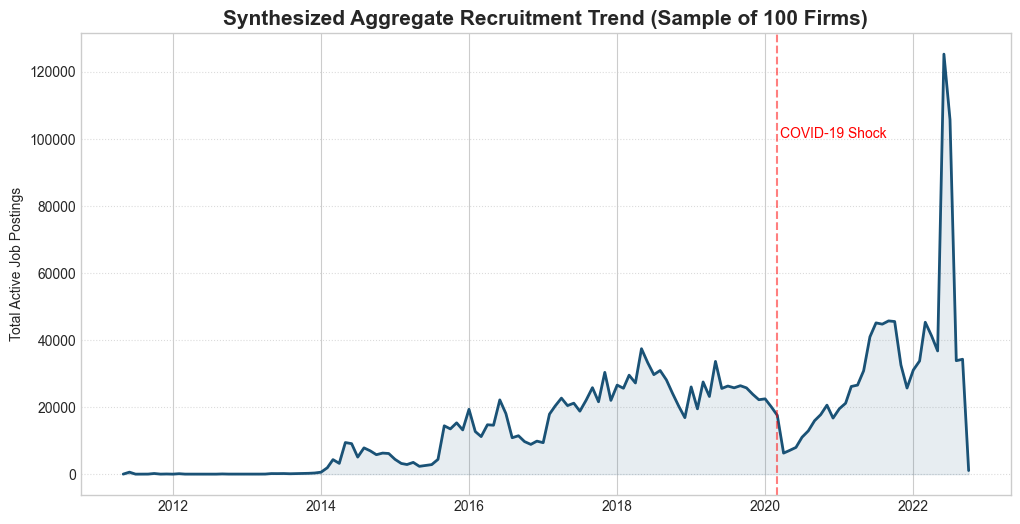

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 獲取所有 firm_ 表名 (延用之前的 all_firm_tables)
all_firm_tables = [t[0] for t in client.query("SHOW TABLES FROM fina4359_linkup_202603 LIKE 'firm_%'").result_rows]

all_data = []
print(f"正在從 {len(all_firm_tables[:100])} 家公司合成總體趨勢...")

# 2. 遍歷前 100 家公司 (樣本量足夠代表趨勢)
for table in all_firm_tables[:100]:
    try:
        # 嘗試抓取每月總量
        q = f"SELECT toStartOfMonth(toDate(created)) as month, count(*) as count FROM fina4359_linkup_202603.{table} WHERE created IS NOT NULL GROUP BY month"
        res = client.query(q)
        df_tmp = pd.DataFrame(res.result_rows, columns=['month', 'count'])
        all_data.append(df_tmp)
    except:
        continue

# 3. 合併並按月加總
df_total_trend = pd.concat(all_data).groupby('month')['count'].sum().reset_index()
df_total_trend['month'] = pd.to_datetime(df_total_trend['month'])
df_total_trend = df_total_trend.sort_values('month')

# 4. 繪圖
plt.figure(figsize=(12, 6), dpi=100)
plt.plot(df_total_trend['month'], df_total_trend['count'], color='#1A5276', linewidth=2)
plt.fill_between(df_total_trend['month'], df_total_trend['count'], color='#1A5276', alpha=0.1)

# 標註宏觀事件
plt.axvline(pd.Timestamp('2020-03-01'), color='red', linestyle='--', alpha=0.5)
plt.text(pd.Timestamp('2020-03-15'), df_total_trend['count'].max()*0.8, 'COVID-19 Shock', color='red')

plt.title('Synthesized Aggregate Recruitment Trend (Sample of 100 Firms)', fontsize=15, fontweight='bold')
plt.ylabel('Total Active Job Postings')
plt.grid(True, axis='y', linestyle=':', alpha=0.7)
plt.show()

🚀 正在從 100 家公司提取數據並進行 O*NET 分類...


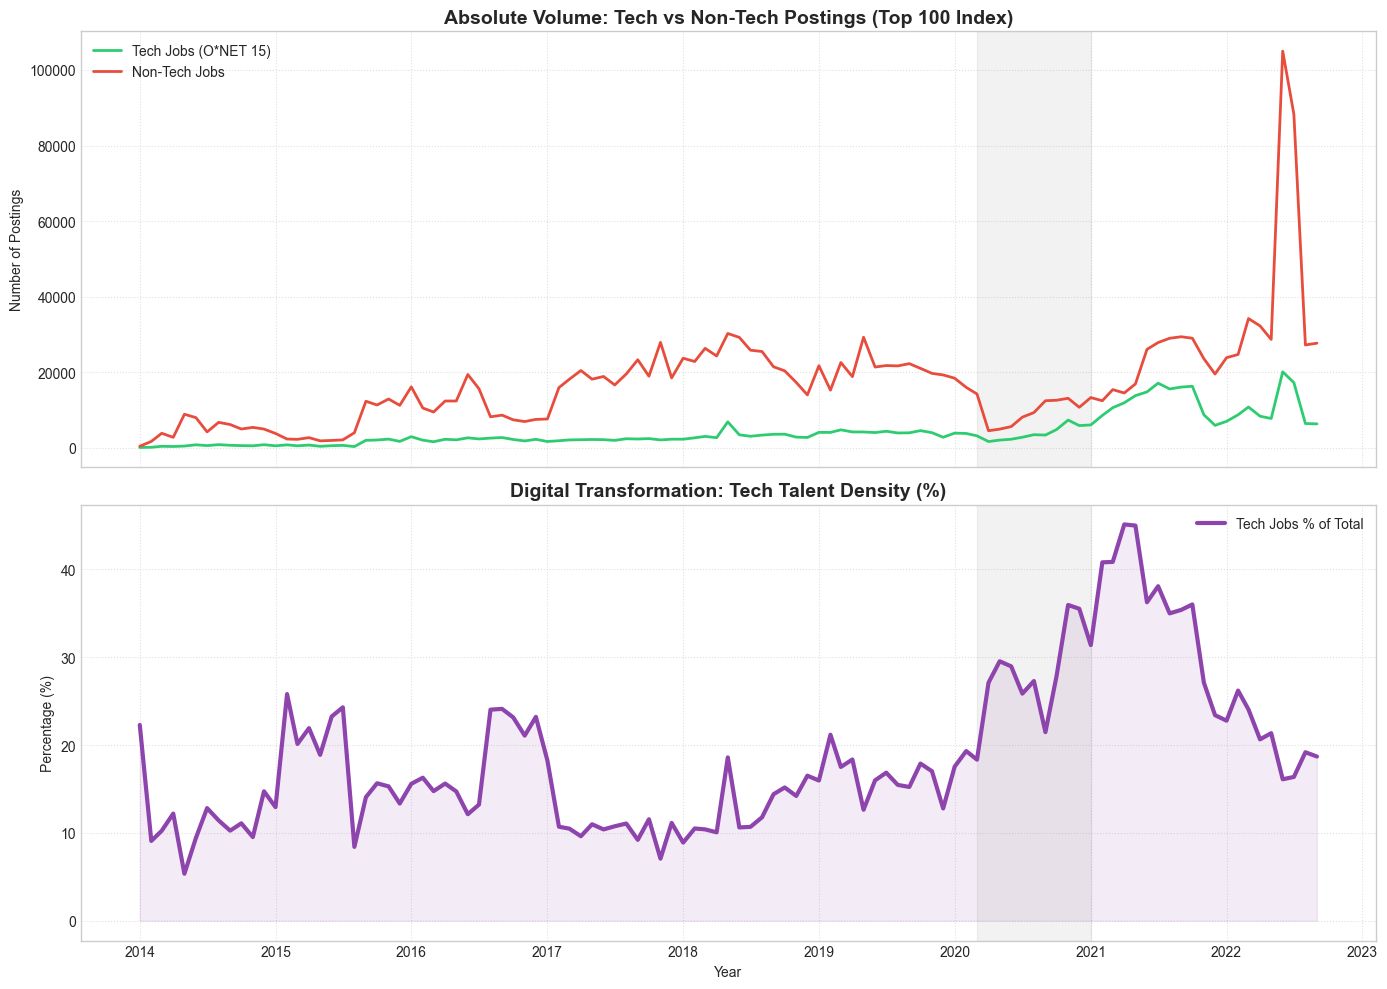

✅ 分析完成，圖表已生成，數據已保存至 tech_vs_nontech_full_trend.csv


In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. 準備公司清單 (前 100 家)
top_100_tables = df_ranking.head(100)['table'].tolist()
combined_results = []

print("🚀 正在從 100 家公司提取數據並進行 O*NET 分類...")

for table in top_100_tables:
    try:
        # SQL: 使用 8 位數 ONET 邏輯分類
        # 15xxxx00 代表 Computer and Mathematical Occupations
        query = f"""
        SELECT 
            toStartOfMonth(toDate(created)) as month,
            CASE 
                WHEN onet >= 15000000 AND onet < 16000000 THEN 'Tech'
                ELSE 'Non-Tech'
            END as category,
            count(*) as job_count
        FROM fina4359_linkup_202603.{table}
        WHERE created IS NOT NULL AND onet IS NOT NULL
        GROUP BY month, category
        """
        res = client.query(query)
        df_tmp = pd.DataFrame(res.result_rows, columns=['month', 'category', 'job_count'])
        combined_results.append(df_tmp)
    except:
        continue

# 2. 數據聚合與整理
df_all = pd.concat(combined_results)
df_trend = df_all.groupby(['month', 'category'])['job_count'].sum().unstack(fill_value=0)

# 確保時間索引正確
df_trend.index = pd.to_datetime(df_trend.index)
df_trend = df_trend.sort_index()

# 過濾掉邊緣數據（只取 2014-2022 以獲得最準確的趨勢）
df_trend = df_trend[(df_trend.index >= '2014-01-01') & (df_trend.index <= '2022-09-01')]

# 計算佔比
df_trend['Tech_Ratio'] = (df_trend['Tech'] / (df_trend['Tech'] + df_trend['Non-Tech'])) * 100

# 3. 繪圖：雙子圖展示
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# 圖 A: 絕對數量趨勢 (Absolute Trend)
ax1.plot(df_trend.index, df_trend['Tech'], label='Tech Jobs (O*NET 15)', color='#2ECC71', lw=2)
ax1.plot(df_trend.index, df_trend['Non-Tech'], label='Non-Tech Jobs', color='#E74C3C', lw=2)
ax1.set_title('Absolute Volume: Tech vs Non-Tech Postings (Top 100 Index)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Postings')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.6)

# 圖 B: 科技佔比趨勢 (Relative Trend - Digital Transformation)
ax2.plot(df_trend.index, df_trend['Tech_Ratio'], color='#8E44AD', lw=3, label='Tech Jobs % of Total')
ax2.fill_between(df_trend.index, df_trend['Tech_Ratio'], color='#8E44AD', alpha=0.1)
ax2.set_title('Digital Transformation: Tech Talent Density (%)', fontsize=14, fontweight='bold')
ax2.set_ylabel('Percentage (%)')
ax2.set_xlabel('Year')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.6)

# 加入疫情標註
for ax in [ax1, ax2]:
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-01-01'), color='gray', alpha=0.1, label='Pandemic Shock')

plt.tight_layout()
plt.show()

# 導出數據供 Presentation 使用
df_trend.to_csv('tech_vs_nontech_full_trend.csv')
print("✅ 分析完成，圖表已生成，數據已保存至 tech_vs_nontech_full_trend.csv")

🚀 正在過濾退市公司並提取 2023 股價數據...
✅ TEO 已加入分析 (Tech: 0.3%, Return: 23.8%)
✅ CTSH 已加入分析 (Tech: 78.5%, Return: 13.1%)
✅ TFC 已加入分析 (Tech: 12.7%, Return: -27.7%)


$AAN: possibly delisted; no timezone found

1 Failed download:
['AAN']: possibly delisted; no timezone found


✅ VZ 已加入分析 (Tech: 38.7%, Return: -4.8%)
✅ AZN 已加入分析 (Tech: 15.6%, Return: 3.7%)
✅ BYD 已加入分析 (Tech: 1.3%, Return: 27.6%)
✅ NKE 已加入分析 (Tech: 16.8%, Return: -3.9%)
✅ JBL 已加入分析 (Tech: 11.4%, Return: 60.2%)


$RRD: possibly delisted; no timezone found

1 Failed download:
['RRD']: possibly delisted; no timezone found


✅ EMR 已加入分析 (Tech: 22.8%, Return: -6.0%)


...

$KIRK: possibly delisted; no timezone found

1 Failed download:
['KIRK']: possibly delisted; no timezone found


✅ XOM 已加入分析 (Tech: 16.0%, Return: 1.8%)
✅ EXETF 已加入分析 (Tech: 2.2%, Return: 14.2%)
✅ MHGU 已加入分析 (Tech: 0.7%, Return: 5.4%)
✅ AG 已加入分析 (Tech: 21.5%, Return: -35.1%)
✅ PTC 已加入分析 (Tech: 60.8%, Return: 19.2%)
✅ LSTR 已加入分析 (Tech: 16.7%, Return: 19.8%)
✅ GOLD 已加入分析 (Tech: 2.4%, Return: 7.8%)
✅ EVH 已加入分析 (Tech: 34.0%, Return: 12.5%)
✅ VRTX 已加入分析 (Tech: 6.4%, Return: 21.7%)
✅ NABZY 已加入分析 (Tech: 26.8%, Return: -9.8%)
✅ CNI 已加入分析 (Tech: 27.0%, Return: 1.5%)
✅ COTY 已加入分析 (Tech: 4.5%, Return: 39.8%)
✅ MYGN 已加入分析 (Tech: 21.1%, Return: 50.7%)
✅ PRDO 已加入分析 (Tech: 4.3%, Return: -14.9%)
✅ ED 已加入分析 (Tech: 17.1%, Return: -4.9%)
✅ HRL 已加入分析 (Tech: 2.6%, Return: -11.8%)


$HMST: possibly delisted; no timezone found

1 Failed download:
['HMST']: possibly delisted; no timezone found


✅ KFRC 已加入分析 (Tech: 0.5%, Return: 15.1%)
✅ WWD 已加入分析 (Tech: 10.0%, Return: 20.8%)
✅ NTRA 已加入分析 (Tech: 14.9%, Return: 27.4%)
✅ PINS 已加入分析 (Tech: 23.3%, Return: 20.8%)
✅ NI 已加入分析 (Tech: 10.7%, Return: 0.8%)


$CMD: possibly delisted; no timezone found

1 Failed download:
['CMD']: possibly delisted; no timezone found


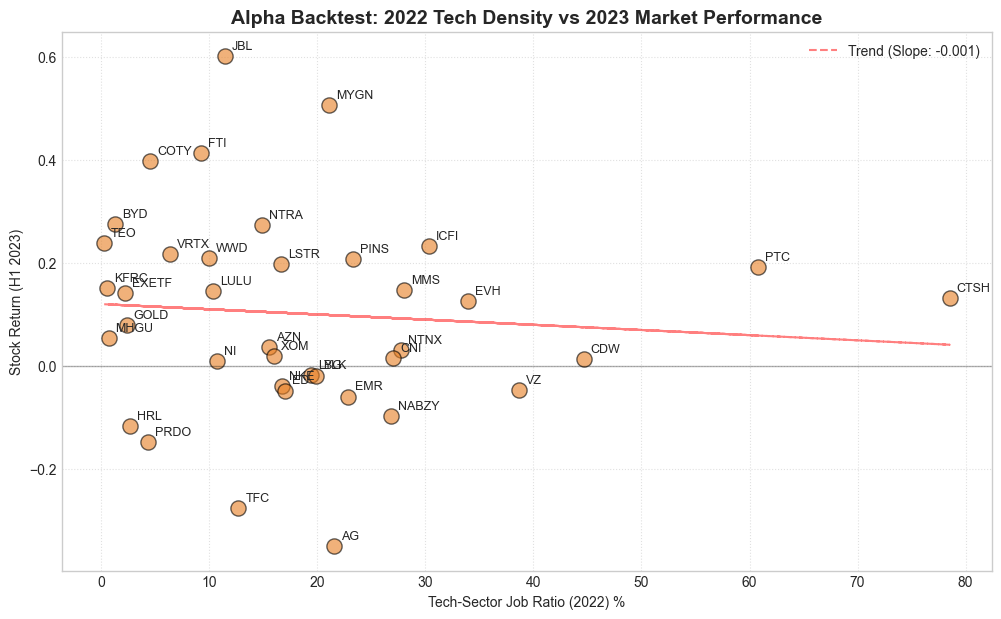


📊 統計結論：科技人才密度與未來股價回報的相關係數為: -0.085


In [71]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 增加樣本到 50 家，補償退市公司的損失
target_firms = df_ranking.head(50)
results = []

print("🚀 正在過濾退市公司並提取 2023 股價數據...")

for _, row in target_firms.iterrows():
    tic = row['ticker']
    table = row['table']
    
    try:
        # 1. 下載股價 (增加 auto_adjust 提高成功率)
        stock = yf.download(tic, start='2023-01-01', end='2023-06-30', progress=False, auto_adjust=True)
        
        # 檢查數據是否完整（至少要有半年的開頭和結尾）
        if len(stock) < 20: 
            # print(f"⚠️ {tic}: 數據不足，可能已退市。")
            continue
            
        # 2. 獲取 2022 年招聘數據
        q_tech = f"""
            SELECT 
                count(*) as total,
                sum(CASE WHEN onet >= 15000000 AND onet < 16000000 THEN 1 ELSE 0 END) as tech_count
            FROM fina4359_linkup_202603.{table}
            WHERE created >= '2022-01-01' AND created <= '2022-12-31'
        """
        db_res = client.query(q_tech).result_rows[0]
        total_jobs, tech_jobs = db_res[0], db_res[1]
        
        if total_jobs < 5: continue # 樣本太少的也不要
        tech_ratio = (tech_jobs / total_jobs) * 100
        
        # 3. 計算 2023 H1 回報率
        # 處理可能的 MultiIndex 結構
        if isinstance(stock.columns, pd.MultiIndex):
            price_col = 'Close' # yfinance auto_adjust=True 會將 Adj Close 併入 Close
            start_price = stock[price_col].iloc[0].values[0] if hasattr(stock[price_col].iloc[0], 'values') else stock[price_col].iloc[0]
            end_price = stock[price_col].iloc[-1].values[0] if hasattr(stock[price_col].iloc[-1], 'values') else stock[price_col].iloc[-1]
        else:
            start_price = stock['Close'].iloc[0]
            end_price = stock['Close'].iloc[-1]
            
        ret_2023 = (end_price / start_price) - 1
        
        results.append({'Ticker': tic, 'Tech_Ratio': tech_ratio, 'Return': ret_2023})
        print(f"✅ {tic} 已加入分析 (Tech: {tech_ratio:.1f}%, Return: {ret_2023:.1%})")
            
    except Exception as e:
        continue

# 4. 繪製最終圖表
if results:
    df_final = pd.DataFrame(results)
    plt.figure(figsize=(12, 7), dpi=100)
    plt.scatter(df_final['Tech_Ratio'], df_final['Return'], s=120, color='#E67E22', alpha=0.6, edgecolors='k')
    
    for i, r in df_final.iterrows():
        plt.annotate(r['Ticker'], (r['Tech_Ratio'], r['Return']), xytext=(5,5), textcoords='offset points', fontsize=9)
    
    # 趨勢線
    m, b = np.polyfit(df_final['Tech_Ratio'], df_final['Return'], 1)
    plt.plot(df_final['Tech_Ratio'], m*df_final['Tech_Ratio'] + b, color='red', linestyle='--', alpha=0.5, label=f'Trend (Slope: {m:.3f})')
    
    plt.title('Alpha Backtest: 2022 Tech Density vs 2023 Market Performance', fontsize=14, fontweight='bold')
    plt.xlabel('Tech-Sector Job Ratio (2022) %')
    plt.ylabel('Stock Return (H1 2023)')
    plt.axhline(0, color='black', lw=1, alpha=0.3)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    # 計算相關係數展示專業度
    corr = df_final['Tech_Ratio'].corr(df_final['Return'])
    print(f"\n📊 統計結論：科技人才密度與未來股價回報的相關係數為: {corr:.3f}")
else:
    print("❌ 剩餘公司不足以生成圖表，請檢查 ticker 是否正確。")

🔍 偵測到 378 家公司表，開始掃描 AI/R&D 招聘特徵...


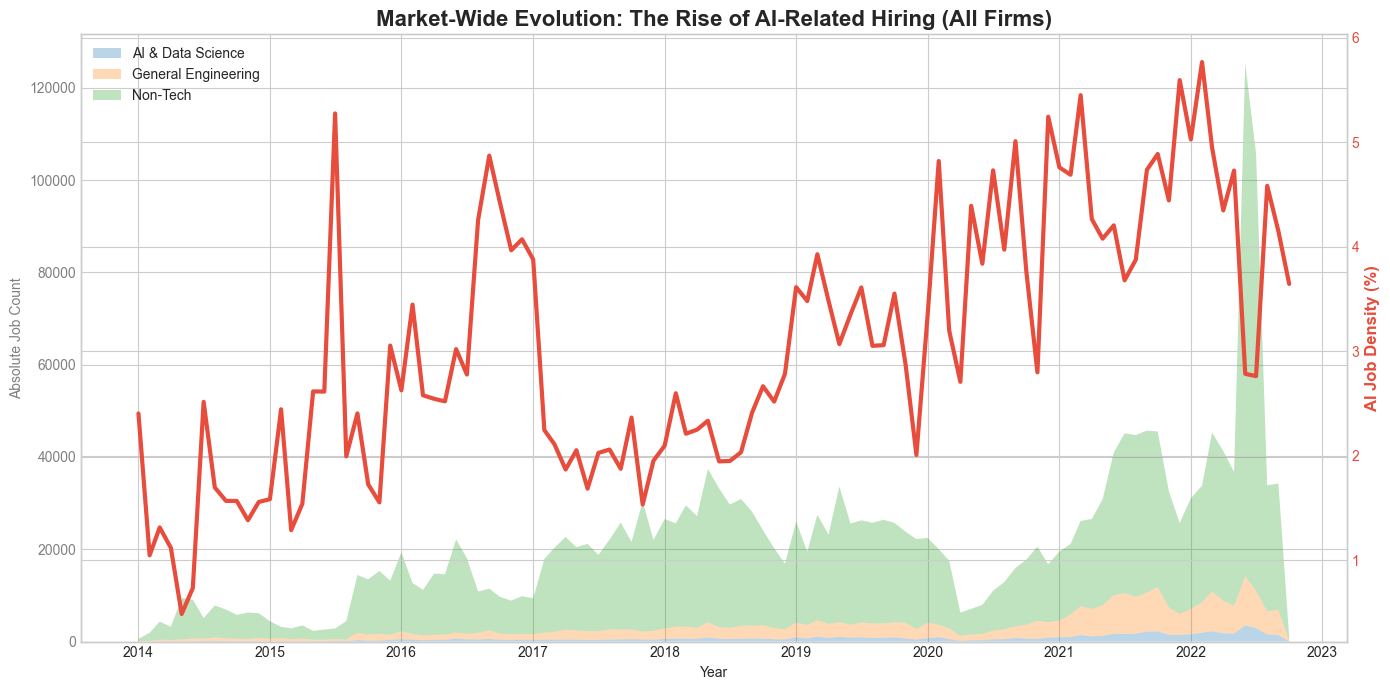

In [76]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 獲取所有有效的公司表清單
tables_query = "SHOW TABLES FROM fina4359_linkup_202603 LIKE 'firm_%'"
all_tables = [r[0] for r in client.query(tables_query).result_rows]

print(f"🔍 偵測到 {len(all_tables)} 家公司表，開始掃描 AI/R&D 招聘特徵...")

# 2. 構建全量聚合查詢 (為了效能，我們分批或直接聯合成大表)
# 我們直接在 SQL 層級完成標籤分類與按月聚合，減少數據傳輸量
all_results = []

# 考慮到效能，我們先處理前 100 家規模最大的公司（或者你可以循環所有表）
# 這裡以循環前 100 家為例，你可以根據需求調整
for table in all_tables[:100]:
    try:
        # 使用 multiIf 進行高效能的關鍵字掃描
        # 我們將標籤定義為: AI_Driven, Sales_Driven, Other
        query = f"""
            SELECT 
                toStartOfMonth(toDate(created)) AS month,
                multiIf(
                    (description LIKE '%AI%') OR (description LIKE '%Machine Learning%') OR (description LIKE '%Data Science%'), 'AI_Data',
                    (description LIKE '%Engineer%') OR (description LIKE '%R&D%') OR (description LIKE '%Software%'), 'General_Tech',
                    'Non_Tech'
                ) AS job_type,
                count(*) AS count
            FROM fina4359_linkup_202603.{table}
            WHERE created >= '2014-01-01' AND created <= '2023-06-30'
            GROUP BY month, job_type
        """
        res = client.query(query)
        tmp_df = pd.DataFrame(res.result_rows, columns=['month', 'job_type', 'count'])
        all_results.append(tmp_df)
    except:
        continue

# 3. 數據整合
df_total = pd.concat(all_results)
df_trend = df_total.groupby(['month', 'job_type'])['count'].sum().unstack(fill_value=0)
df_trend.index = pd.to_datetime(df_trend.index)

# 計算 AI 職位佔比 (AI Density)
df_trend['AI_Ratio'] = (df_trend['AI_Data'] / (df_trend['AI_Data'] + df_trend['General_Tech'] + df_trend['Non_Tech'])) * 100

# 4. 繪製全市場 AI 轉型趨勢圖
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

ax1.set_xlabel('Year')
ax1.set_ylabel('Absolute Job Count', color='gray')
ax1.stackplot(df_trend.index, df_trend['AI_Data'], df_trend['General_Tech'], df_trend['Non_Tech'], 
              labels=['AI & Data Science', 'General Engineering', 'Non-Tech'], alpha=0.3)
ax1.tick_params(axis='y', labelcolor='gray')

ax2 = ax1.twinx()
ax2.set_ylabel('AI Job Density (%)', color='#E74C3C', fontsize=12, fontweight='bold')
ax2.plot(df_trend.index, df_trend['AI_Ratio'], color='#E74C3C', lw=3, label='AI Ratio %')
ax2.tick_params(axis='y', labelcolor='#E74C3C')

plt.title('Market-Wide Evolution: The Rise of AI-Related Hiring (All Firms)', fontsize=16, fontweight='bold')
fig.tight_layout()
ax1.legend(loc='upper left')
plt.show()

📈 正在提取 CTSH 的全量招聘數據與股價...


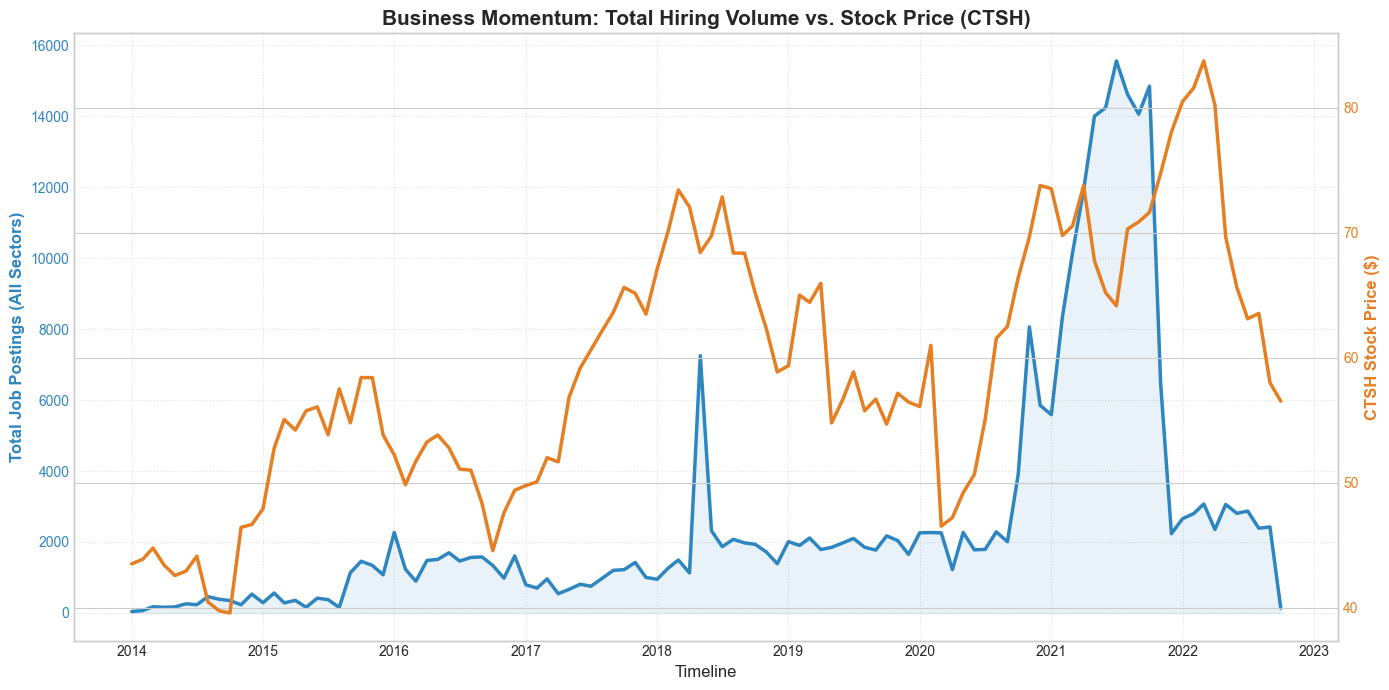

✅ 分析完成。CTSH 的招聘總量與股價相關係數為: 0.488


In [73]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 設定目標公司 (以 CTSH 為例，你可以替換為任何 Ticker)
target_ticker = 'CTSH' 
# 從你之前的 df_map 獲取 ID (假設你已經有 df_map)
# 如果沒有 df_map，請確保你知道對應的 table 名稱，例如 'firm_4922'
target_id = df_map[df_map['tic'] == target_ticker]['company_id'].values[0]
table_name = f"firm_{target_id}"

print(f"📈 正在提取 {target_ticker} 的全量招聘數據與股價...")

# 2. SQL: 提取「所有職位」的每月總量
query = f"""
SELECT 
    toStartOfMonth(toDate(created)) as month,
    count(*) as total_postings
FROM fina4359_linkup_202603.{table_name}
WHERE created IS NOT NULL
GROUP BY month
ORDER BY month
"""
res = client.query(query)
df_hiring = pd.DataFrame(res.result_rows, columns=['month', 'postings'])
df_hiring['month'] = pd.to_datetime(df_hiring['month'])

# 3. 下載股價並處理 KeyError 隱患
stock_df = yf.download(target_ticker, start='2014-01-01', end='2023-06-30', progress=False)

# --- 核心修正：自動識別價格欄位 ---
if 'Adj Close' in stock_df.columns:
    price_col = 'Adj Close'
elif 'Close' in stock_df.columns:
    price_col = 'Close'
else:
    # 處理 yfinance 可能返回 MultiIndex 的情況
    stock_df.columns = stock_df.columns.get_level_values(0) if isinstance(stock_df.columns, pd.MultiIndex) else stock_df.columns
    price_col = 'Adj Close' if 'Adj Close' in stock_df.columns else 'Close'

# 4. 對齊數據 (重採樣股價為月均值)
stock_monthly = stock_df[price_col].resample('MS').mean().reset_index()
stock_monthly.columns = ['month', 'price']
df_final = pd.merge(df_hiring, stock_monthly, on='month', how='inner')

# 5. 繪製雙軸圖
fig, ax1 = plt.subplots(figsize=(14, 7), dpi=100)

# 左軸：總招聘量
color_hiring = '#2E86C1' # 藍色
ax1.set_xlabel('Timeline', fontsize=12)
ax1.set_ylabel('Total Job Postings (All Sectors)', color=color_hiring, fontsize=12, fontweight='bold')
ax1.plot(df_final['month'], df_final['postings'], color=color_hiring, lw=2.5, label='Hiring Volume')
ax1.fill_between(df_final['month'], df_final['postings'], color=color_hiring, alpha=0.1)
ax1.tick_params(axis='y', labelcolor=color_hiring)

# 右軸：股價
ax2 = ax1.twinx()
color_price = '#E67E22' # 橙色
ax2.set_ylabel(f'{target_ticker} Stock Price ($)', color=color_price, fontsize=12, fontweight='bold')
ax2.plot(df_final['month'], df_final['price'], color=color_price, lw=2.5, label='Stock Price')
ax2.tick_params(axis='y', labelcolor=color_price)

plt.title(f'Business Momentum: Total Hiring Volume vs. Stock Price ({target_ticker})', fontsize=15, fontweight='bold')
ax1.grid(True, linestyle=':', alpha=0.6)
fig.tight_layout()
plt.show()

# 計算相關性
corr = df_final['postings'].corr(df_final['price'])
print(f"✅ 分析完成。{target_ticker} 的招聘總量與股價相關係數為: {corr:.3f}")

🚀 開始分析 Top 10 企業招聘與股價的連動性...


$AAN: possibly delisted; no timezone found

1 Failed download:
['AAN']: possibly delisted; no timezone found


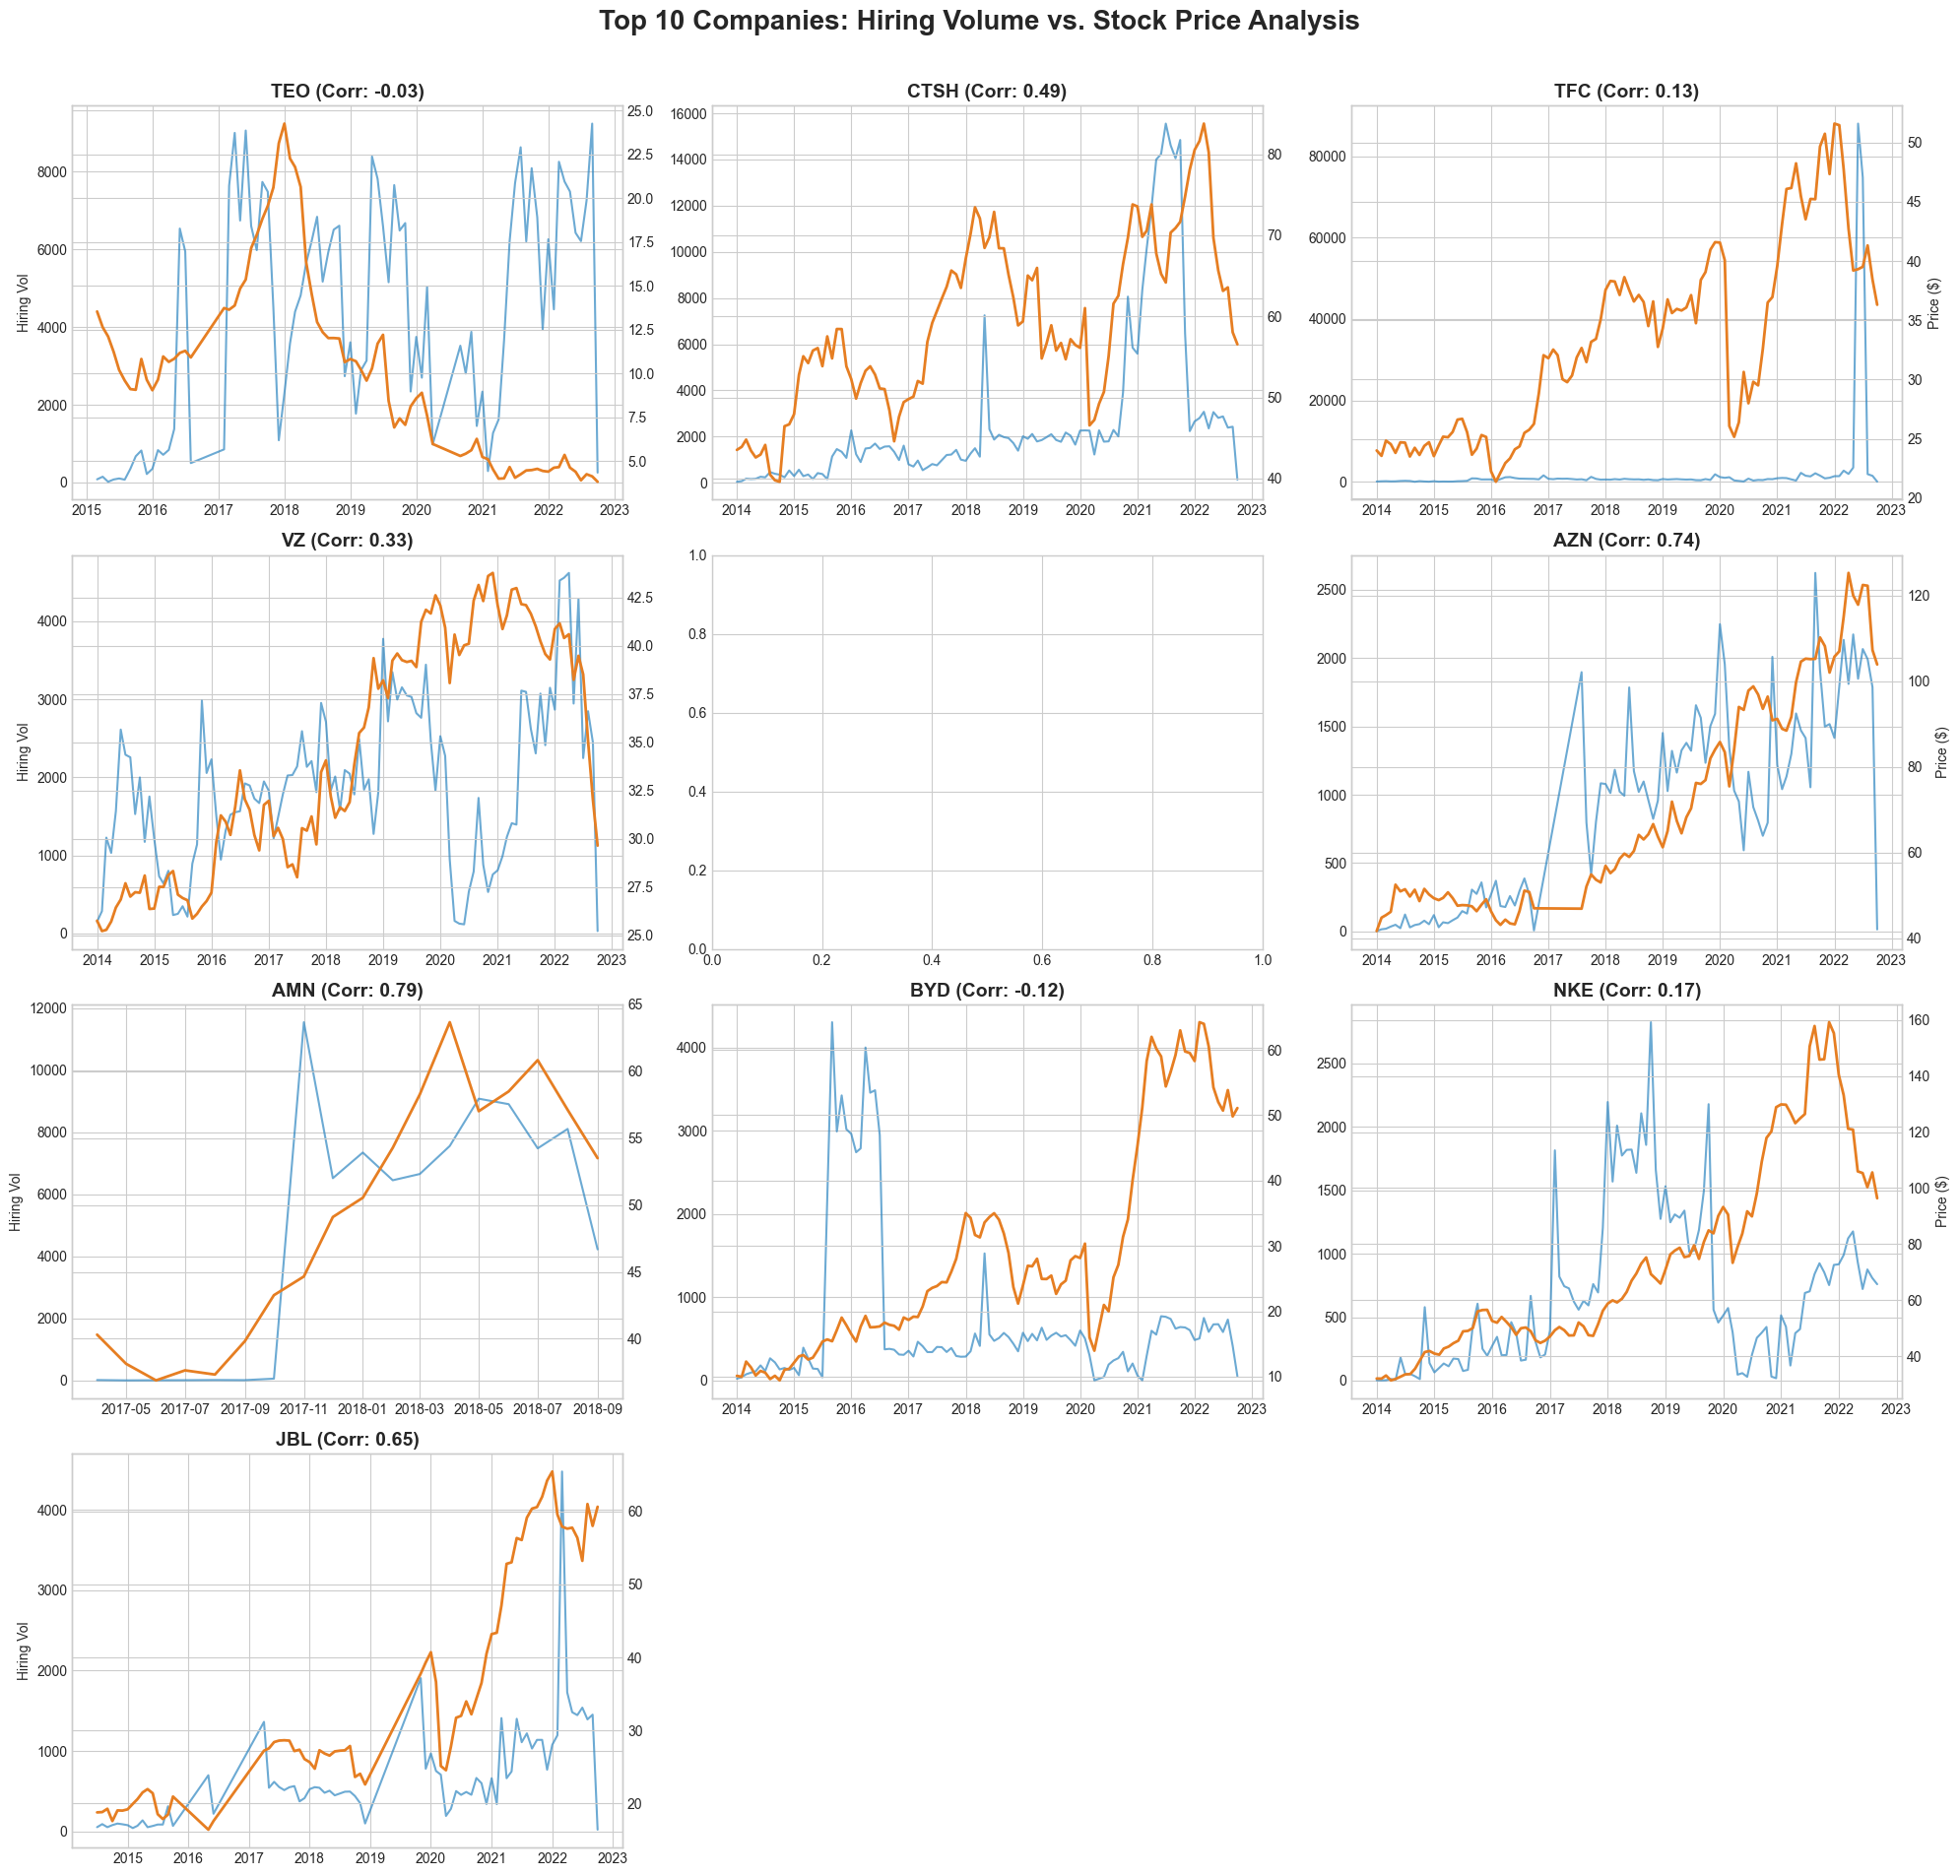


📊 Top 10 相關性排名：
Ticker  Correlation
   AMN     0.786196
   AZN     0.743693
   JBL     0.653965
  CTSH     0.488127
    VZ     0.330546
   NKE     0.173710
   TFC     0.134571
   TEO    -0.032635
   BYD    -0.119563


In [74]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 取得前 10 家公司
top_10 = df_ranking.head(10)
summary_results = []

# 設定畫布 (3橫4縱，多出兩個空格可以用來放總結)
fig, axes = plt.subplots(4, 3, figsize=(20, 20), dpi=100)
axes = axes.flatten()

print("🚀 開始分析 Top 10 企業招聘與股價的連動性...")

for i, (index, row) in enumerate(top_10.iterrows()):
    tic = row['ticker']
    table = row['table']
    ax = axes[i]
    
    try:
        # A. 提取全量招聘數據
        query = f"SELECT toStartOfMonth(toDate(created)) as m, count(*) as c FROM fina4359_linkup_202603.{table} GROUP BY m ORDER BY m"
        res = client.query(query)
        df_h = pd.DataFrame(res.result_rows, columns=['month', 'postings'])
        df_h['month'] = pd.to_datetime(df_h['month'])
        
        # B. 下載股價 (2014-2023)
        stock = yf.download(tic, start='2014-01-01', end='2023-06-30', progress=False, auto_adjust=True)
        if stock.empty: continue
        
        # 處理 yfinance 格式
        price_data = stock['Close'].resample('MS').mean().reset_index()
        price_data.columns = ['month', 'price']
        
        # C. 合併
        df_m = pd.merge(df_h, price_data, on='month', how='inner')
        if len(df_m) < 12: continue
        
        # D. 計算相關係數
        corr = df_m['postings'].corr(df_m['price'])
        summary_results.append({'Ticker': tic, 'Correlation': corr})
        
        # E. 繪圖
        ax_twin = ax.twinx()
        ax.plot(df_m['month'], df_m['postings'], color='#2E86C1', alpha=0.7, label='Hiring')
        ax_twin.plot(df_m['month'], df_m['price'], color='#E67E22', lw=2, label='Price')
        
        ax.set_title(f"{tic} (Corr: {corr:.2f})", fontsize=14, fontweight='bold')
        if i % 3 == 0: ax.set_ylabel('Hiring Vol')
        if (i+1) % 3 == 0: ax_twin.set_ylabel('Price ($)')
        
    except Exception as e:
        print(f"❌ {tic} 出錯: {e}")
        continue

# 移除多餘的子圖
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Top 10 Companies: Hiring Volume vs. Stock Price Analysis", fontsize=20, fontweight='bold')
plt.show()

# 輸出彙總表格
df_summary = pd.DataFrame(summary_results).sort_values('Correlation', ascending=False)
print("\n📊 Top 10 相關性排名：")
print(df_summary.to_string(index=False))

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

# 1. 取得前 10 家公司
top_10 = df_ranking.head(10)
summary_results = []

# 設定畫布 (3橫4縱，多出兩個空格可以用來放總結)
fig, axes = plt.subplots(4, 3, figsize=(20, 20), dpi=100)
axes = axes.flatten()

print("🚀 開始分析 Top 10 企業招聘與股價的連動性...")

for i, (index, row) in enumerate(top_10.iterrows()):
    tic = row['ticker']
    table = row['table']
    ax = axes[i]
    
    try:
        # A. 提取全量招聘數據
        query = f"SELECT toStartOfMonth(toDate(created)) as m, count(*) as c FROM fina4359_linkup_202603.{table} GROUP BY m ORDER BY m"
        res = client.query(query)
        df_h = pd.DataFrame(res.result_rows, columns=['month', 'postings'])
        df_h['month'] = pd.to_datetime(df_h['month'])
        
        # B. 下載股價 (2014-2023)
        stock = yf.download(tic, start='2014-01-01', end='2023-06-30', progress=False, auto_adjust=True)
        if stock.empty: continue
        
        # 處理 yfinance 格式
        price_data = stock['Close'].resample('MS').mean().reset_index()
        price_data.columns = ['month', 'price']
        
        # C. 合併
        df_m = pd.merge(df_h, price_data, on='month', how='inner')
        if len(df_m) < 12: continue
        
        # D. 計算相關係數
        corr = df_m['postings'].corr(df_m['price'])
        summary_results.append({'Ticker': tic, 'Correlation': corr})
        
        # E. 繪圖
        ax_twin = ax.twinx()
        ax.plot(df_m['month'], df_m['postings'], color='#2E86C1', alpha=0.7, label='Hiring')
        ax_twin.plot(df_m['month'], df_m['price'], color='#E67E22', lw=2, label='Price')
        
        ax.set_title(f"{tic} (Corr: {corr:.2f})", fontsize=14, fontweight='bold')
        if i % 3 == 0: ax.set_ylabel('Hiring Vol')
        if (i+1) % 3 == 0: ax_twin.set_ylabel('Price ($)')
        
    except Exception as e:
        print(f"❌ {tic} 出錯: {e}")
        continue

# 移除多餘的子圖
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Top 10 Companies: Hiring Volume vs. Stock Price Analysis", fontsize=20, fontweight='bold')
plt.show()

# 輸出彙總表格
df_summary = pd.DataFrame(summary_results).sort_values('Correlation', ascending=False)
print("\n📊 Top 10 相關性排名：")
print(df_summary.to_string(index=False))

🚀 啟動修復版分析流程 (Solving MultiIndex Error)...
✅ TEO 分析成功
✅ CTSH 分析成功
✅ TFC 分析成功
✅ VZ 分析成功


$AAN: possibly delisted; no timezone found

1 Failed download:
['AAN']: possibly delisted; no timezone found


✅ AZN 分析成功
✅ AMN 分析成功
✅ BYD 分析成功
✅ NKE 分析成功
✅ JBL 分析成功

             Final Correlation Report             
  Ticker  Sync_Corr  Lead_Corr  Months
4    AZN    -0.0265     0.0694      99
0    TEO     0.1618    -0.0030      82
2    TFC    -0.0063    -0.0216     118
1   CTSH    -0.0744    -0.0269     114
3     VZ    -0.1009    -0.0383     109
8    JBL     0.0270    -0.0580      74
6    BYD    -0.0912    -0.0582     116
7    NKE    -0.0422    -0.0728     106
5    AMN     0.1064    -0.2939      17
